In [1]:
# ML Models

Data shape: (11430, 89)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0         

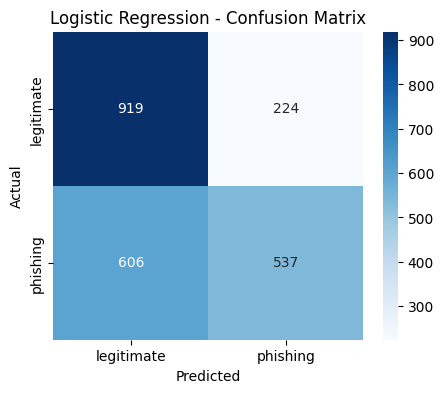


===== Naive Bayes =====
Accuracy:  0.6413
Precision: 0.6703
Recall:    0.6413
F1 Score:  0.6253
MCC:       0.3103


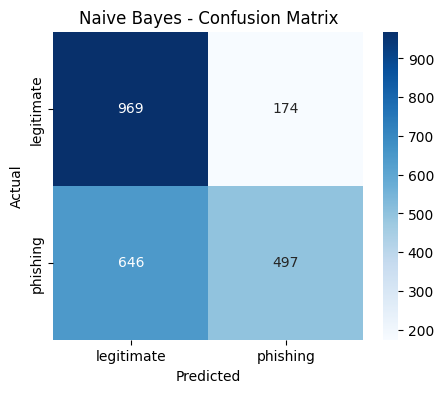


===== Random Forest =====
Accuracy:  0.6960
Precision: 0.6988
Recall:    0.6960
F1 Score:  0.6949
MCC:       0.3948


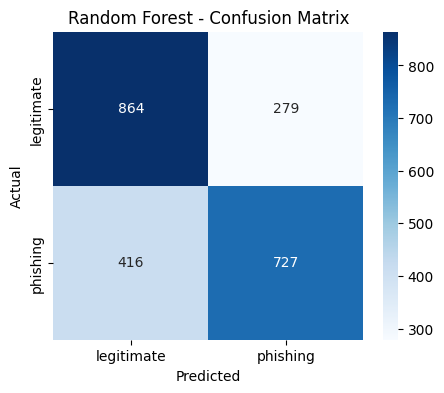


===== XGBoost =====
Accuracy:  0.7100
Precision: 0.7141
Recall:    0.7100
F1 Score:  0.7086
MCC:       0.4241


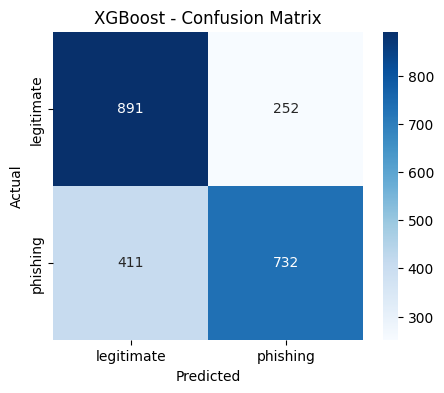


=== Model Performance Comparison ===
                 Model  Accuracy  Precision    Recall  F1 Score       MCC
0  Logistic Regression  0.636920   0.654137  0.636920  0.626491  0.290547
1          Naive Bayes  0.641295   0.670343  0.641295  0.625322  0.310281
2        Random Forest  0.695976   0.698832  0.695976  0.694880  0.394797
3              XGBoost  0.709974   0.714117  0.709974  0.708564  0.424071


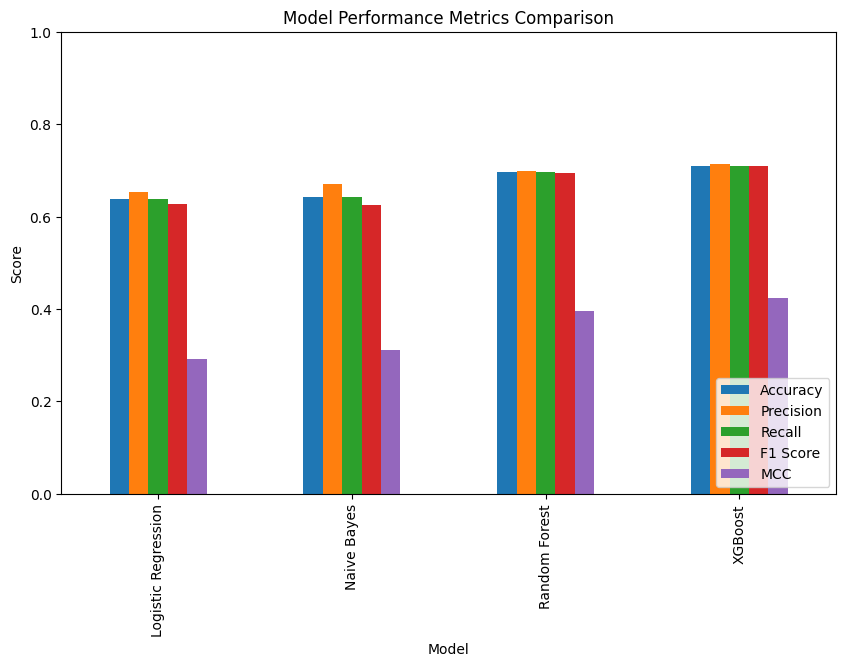

In [2]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ================================
# 2. Load Raw URL Dataset
# ================================
# Replace with your dataset path containing at least columns "url" and "target"
df = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")

print("Data shape:", df.shape)
print(df.head())

# ================================
# 3. Encode Labels
# ================================
le = LabelEncoder()
y = le.fit_transform(df["status"].values)  # e.g., 'legitimate' -> 0, 'phishing' -> 1

# ================================
# 4. Extract Minimal URL Features
# ================================
df['url_length'] = df['url'].astype(str).str.len()
df['num_digits'] = df['url'].str.count(r'\d')
df['num_special'] = df['url'].str.count(r'[^a-zA-Z0-9]')

X = df[['url_length', 'num_digits', 'num_special']].values

print("Feature matrix shape:", X.shape)
print("Number of samples:", len(y))
print("Classes:", np.unique(y))

# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Define Models (baseline)
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# ================================
# 7. Train, Predict & Collect Metrics
# ================================
metrics_results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)
    
    metrics_results.append([name, acc, prec, rec, f1, mcc])
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Free memory
    del y_pred, cm
    gc.collect()

# ================================
# 8. Compare Models in Table
# ================================
results_df = pd.DataFrame(
    metrics_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
)

print("\n=== Model Performance Comparison ===")
print(results_df)

# ================================
# 9. Plot Model Comparison
# ================================
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


In [3]:
# word Embedding Techniques need To Apply ML and DL Models

In [4]:
 # word2vec Algorithm-ML Models

Data shape: (11430, 89)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0         

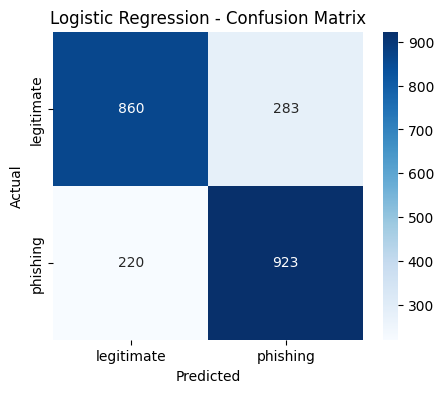


===== Naive Bayes =====
Accuracy:  0.6409
Precision: 0.6635
Recall:    0.6409
F1 Score:  0.6280
MCC:       0.3035


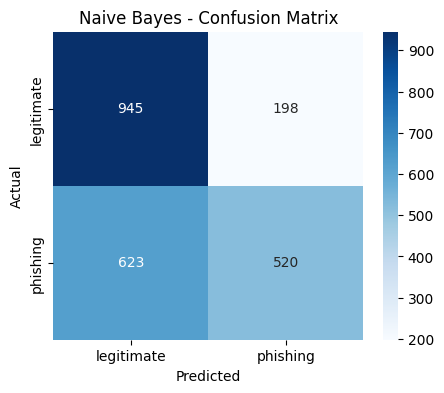


===== Random Forest =====
Accuracy:  0.8513
Precision: 0.8526
Recall:    0.8513
F1 Score:  0.8511
MCC:       0.7039


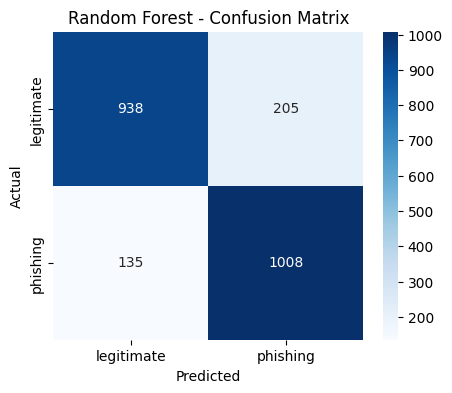


===== XGBoost =====
Accuracy:  0.8526
Precision: 0.8529
Recall:    0.8526
F1 Score:  0.8526
MCC:       0.7055


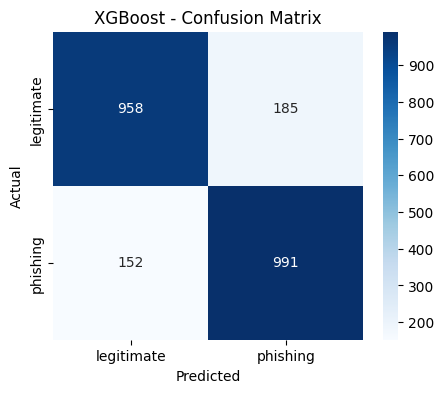


=== Model Performance Comparison ===
                 Model  Accuracy  Precision    Recall  F1 Score       MCC
0  Logistic Regression  0.779965   0.780818  0.779965  0.779798  0.560782
1          Naive Bayes  0.640857   0.663456  0.640857  0.628000  0.303473
2        Random Forest  0.851269   0.852591  0.851269  0.851129  0.703858
3              XGBoost  0.852581   0.852875  0.852581  0.852550  0.705456


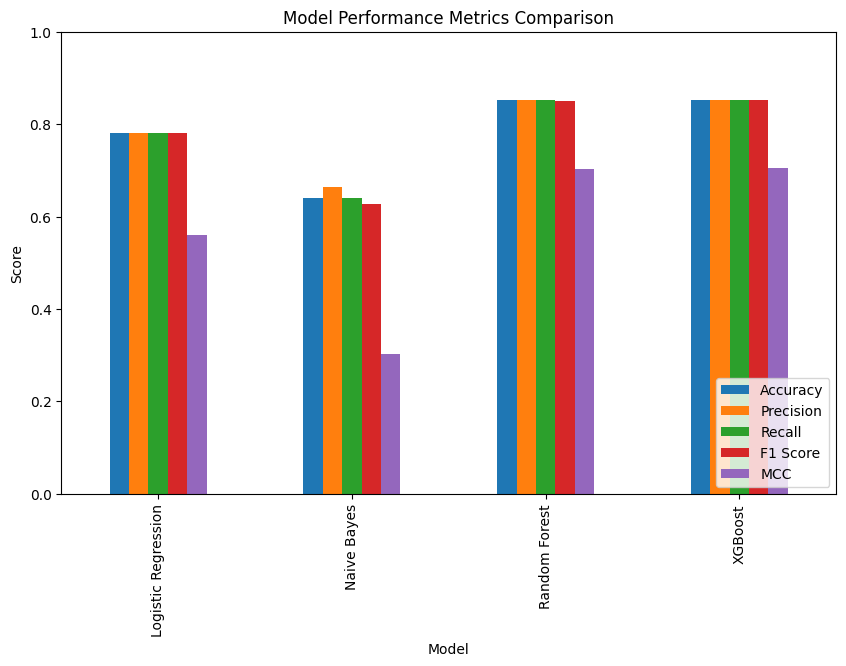

In [5]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ================================
# 2. Load Raw URL Dataset
# ================================
# Replace with your dataset path containing at least columns "url" and "target"
df = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")

print("Data shape:", df.shape)
print(df.head())

# ================================
# 3. Encode Labels
# ================================
le = LabelEncoder()
y = le.fit_transform(df["status"].values)  # e.g., 'legitimate' -> 0, 'phishing' -> 1

# word2vec Embeddings
from gensim.models import Word2Vec
import re

# Tokenize URLs
def tokenize_url(url):
    tokens = re.split(r'[./:?&=]', url)
    tokens = [t for t in tokens if t]  # remove empty strings
    return tokens

sentences = df['url'].astype(str).apply(tokenize_url).tolist()

# Train Word2Vec
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Convert each URL to vector (average of word vectors)
def url_to_vec(url):
    tokens = tokenize_url(url)
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if len(vecs) == 0:
        return np.zeros(100)
    return np.mean(vecs, axis=0)

X = np.array(df['url'].astype(str).apply(url_to_vec).tolist())

# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Define Models (baseline)
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),  # switched from MultinomialNB
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# ================================
# 7. Train, Predict & Collect Metrics
# ================================
metrics_results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)
    
    metrics_results.append([name, acc, prec, rec, f1, mcc])
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Free memory
    del y_pred, cm
    gc.collect()

# ================================
# 8. Compare Models in Table
# ================================
results_df = pd.DataFrame(
    metrics_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
)

print("\n=== Model Performance Comparison ===")
print(results_df)

# ================================
# 9. Plot Model Comparison
# ================================
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


In [6]:
 # FastText Algorithm-ML Models

Data shape: (11430, 89)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0         

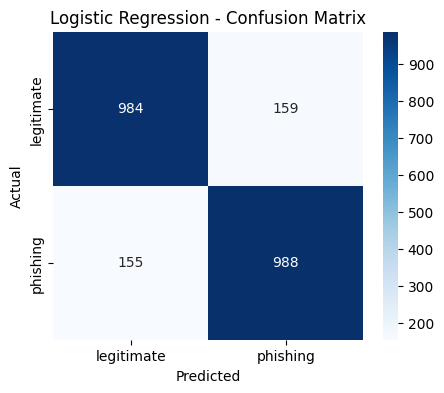


===== Naive Bayes =====
Accuracy:  0.7620
Precision: 0.8016
Recall:    0.7620
F1 Score:  0.7540
MCC:       0.5622


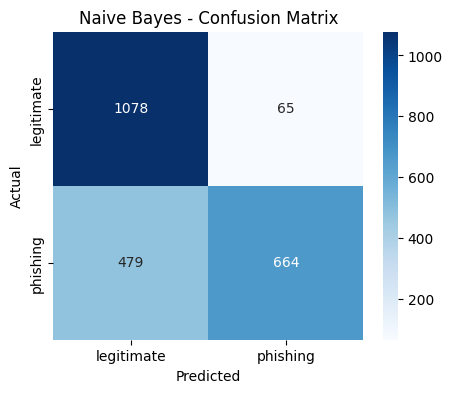


===== Random Forest =====
Accuracy:  0.9151
Precision: 0.9151
Recall:    0.9151
F1 Score:  0.9151
MCC:       0.8303


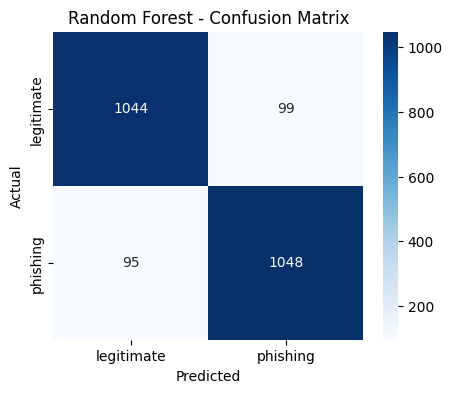


===== XGBoost =====
Accuracy:  0.9116
Precision: 0.9117
Recall:    0.9116
F1 Score:  0.9116
MCC:       0.8234


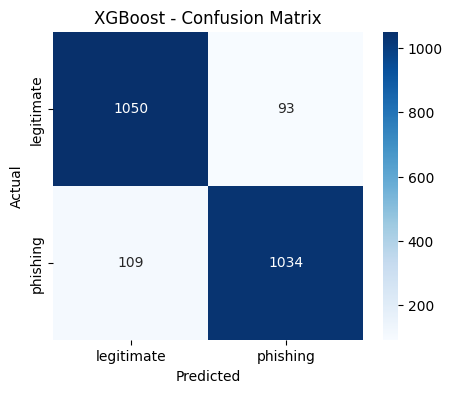


=== Model Performance Comparison ===
                 Model  Accuracy  Precision    Recall  F1 Score       MCC
0  Logistic Regression  0.862642   0.862647  0.862642  0.862642  0.725289
1          Naive Bayes  0.762030   0.801597  0.762030  0.753960  0.562236
2        Random Forest  0.915136   0.915141  0.915136  0.915135  0.830276
3              XGBoost  0.911636   0.911717  0.911636  0.911632  0.823353


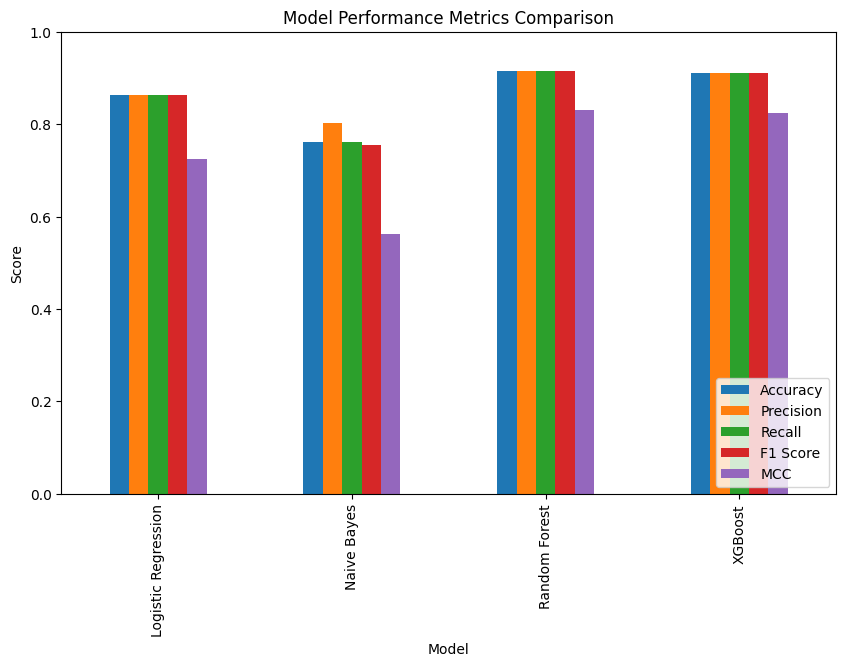

In [7]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# FastText
from gensim.models import FastText

# ================================
# 2. Load Raw URL Dataset
# ================================
# Replace with your dataset path containing columns "url" and "status"
df = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")

print("Data shape:", df.shape)
print(df.head())

# ================================
# 3. Encode Labels
# ================================
le = LabelEncoder()
y = le.fit_transform(df["status"].values)  # 'legitimate' -> 0, 'phishing' -> 1

# ================================
# 4. Tokenize URLs for FastText
# ================================
def tokenize_url(url):
    tokens = re.split(r'[./:?&=-]', url)
    tokens = [t for t in tokens if t]  # remove empty strings
    return tokens

sentences = df['url'].astype(str).apply(tokenize_url).tolist()

# ================================
# 5. Train FastText Model
# ================================
ft_model = FastText(
    sentences=sentences,
    vector_size=100,  # embedding size
    window=5,
    min_count=1,
    workers=4,
    sg=1,  # skip-gram
    seed=42
)

# ================================
# 6. Convert URLs to Embeddings
# ================================
def url_to_vec(url):
    tokens = tokenize_url(url)
    vecs = [ft_model.wv[t] for t in tokens if t in ft_model.wv]
    if len(vecs) == 0:
        return np.zeros(100)
    return np.mean(vecs, axis=0)

X = np.array(df['url'].astype(str).apply(url_to_vec).tolist())
print("Feature matrix shape:", X.shape)
print("Number of samples:", len(y))
print("Classes:", np.unique(y))

# ================================
# 7. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 8. Define Baseline ML Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),  # works with continuous embeddings
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# ================================
# 9. Train, Predict & Collect Metrics
# ================================
metrics_results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)
    
    metrics_results.append([name, acc, prec, rec, f1, mcc])
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Free memory
    del y_pred, cm
    gc.collect()

# ================================
# 10. Compare Models in Table
# ================================
results_df = pd.DataFrame(
    metrics_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
)

print("\n=== Model Performance Comparison ===")
print(results_df)

# ================================
# 11. Plot Model Comparison
# ================================
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


In [8]:
# word2vec Algorithm-DL Models 5Epochs For Testing dobby..!

2025-10-06 18:31:19.115982: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759775479.364319      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759775479.434425      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Data shape: (11430, 89)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0         

I0000 00:00:1759775493.468331      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759775493.468923      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



===== 1D CNN =====
Epoch 1/5


I0000 00:00:1759775497.352378     187 service.cc:148] XLA service 0x2fad43a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759775497.353236     187 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759775497.353255     187 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759775497.627346     187 cuda_dnn.cc:529] Loaded cuDNN version 90300


 59/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6629 - loss: 0.5694

I0000 00:00:1759775500.223201     187 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7072 - loss: 0.5283 - val_accuracy: 0.8087 - val_loss: 0.4229
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7918 - loss: 0.4380 - val_accuracy: 0.8197 - val_loss: 0.4036
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8024 - loss: 0.4182 - val_accuracy: 0.8087 - val_loss: 0.4016
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8044 - loss: 0.4080 - val_accuracy: 0.8219 - val_loss: 0.3913
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8067 - loss: 0.4119 - val_accuracy: 0.8120 - val_loss: 0.4096
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy:  0.8154
Precision: 0.8217
Recall:    0.8154
F1 Score:  0.8145
MCC:       0.6371


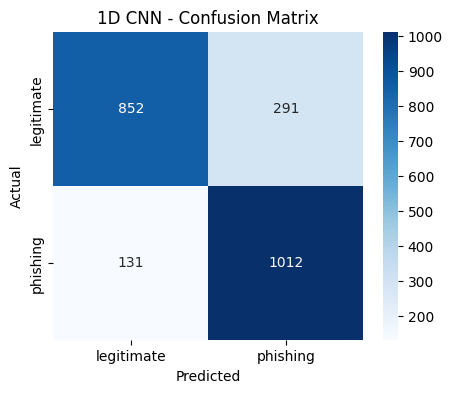


===== LSTM =====
Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5844 - loss: 0.6556 - val_accuracy: 0.6787 - val_loss: 0.5555
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7442 - loss: 0.5163 - val_accuracy: 0.8033 - val_loss: 0.4328
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7758 - loss: 0.4884 - val_accuracy: 0.7956 - val_loss: 0.4522
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7943 - loss: 0.4507 - val_accuracy: 0.7891 - val_loss: 0.4338
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7884 - loss: 0.4432 - val_accuracy: 0.8000 - val_loss: 0.4116
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy:  0.7966
Precision: 0.8184
Recall:    0.7966
F1 Score:  0.7930
MCC:       0.6146


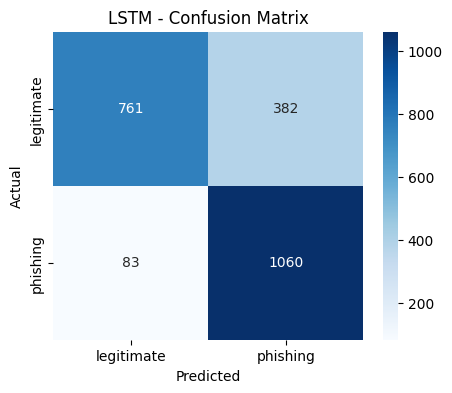


===== BiLSTM =====
Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6784 - loss: 0.5709 - val_accuracy: 0.7989 - val_loss: 0.4232
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7800 - loss: 0.4598 - val_accuracy: 0.7913 - val_loss: 0.4195
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7915 - loss: 0.4387 - val_accuracy: 0.7902 - val_loss: 0.4246
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7967 - loss: 0.4264 - val_accuracy: 0.7814 - val_loss: 0.4282
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7972 - loss: 0.4215 - val_accuracy: 0.7858 - val_loss: 0.4034
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy:  0.7997
Precision: 0.8001
Recall:    0.7997
F1 Score:  0.7996
MCC:       0.5997


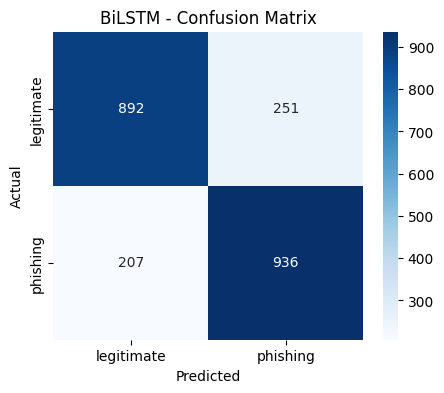


=== Deep Learning Model Performance Comparison ===
    Model  Accuracy  Precision    Recall  F1 Score       MCC
0  1D CNN  0.815398   0.821702  0.815398  0.814489  0.637069
1    LSTM  0.796588   0.818374  0.796588  0.793047  0.614576
2  BiLSTM  0.799650   0.800095  0.799650  0.799576  0.599745


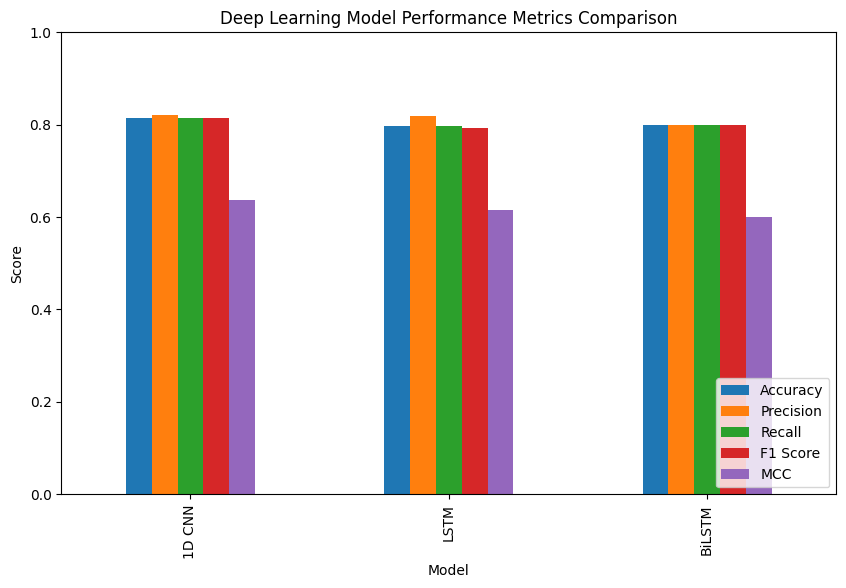

In [9]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import re
import warnings
warnings.filterwarnings("ignore")  # suppress other warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Word2Vec
from gensim.models import Word2Vec

# ================================
# 2. Load Raw URL Dataset
# ================================
df = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")
print("Data shape:", df.shape)
print(df.head())

# ================================
# 3. Encode Labels
# ================================
le = LabelEncoder()
y = le.fit_transform(df["status"].values)  # 'legitimate' -> 0, 'phishing' -> 1
num_classes = len(np.unique(y))
y_categorical = to_categorical(y, num_classes=num_classes)

# ================================
# 4. Tokenize URLs & Train Word2Vec
# ================================
def tokenize_url(url):
    tokens = re.split(r'[./:?&=]', url)
    tokens = [t for t in tokens if t]
    return tokens

sentences = df['url'].astype(str).apply(tokenize_url).tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

def url_to_vec(url, max_len=50):
    tokens = tokenize_url(url)
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if len(vecs) == 0:
        vecs = [np.zeros(100)]
    # Pad/truncate to max_len
    if len(vecs) < max_len:
        vecs += [np.zeros(100)] * (max_len - len(vecs))
    else:
        vecs = vecs[:max_len]
    return np.array(vecs)

X = np.array(df['url'].astype(str).apply(url_to_vec).tolist())
print("Feature matrix shape:", X.shape)  # (samples, max_len, embedding_dim)

# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Define Deep Learning Models
# ================================
def build_1d_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

models = {
    "1D CNN": build_1d_cnn(X_train.shape[1:], num_classes),
    "LSTM": build_lstm(X_train.shape[1:], num_classes),
    "BiLSTM": build_bilstm(X_train.shape[1:], num_classes)
}

# ================================
# 7. Train, Predict & Collect Metrics
# ================================
metrics_results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)
    
    metrics_results.append([name, acc, prec, rec, f1, mcc])
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Free memory
    del y_pred, y_pred_probs, cm
    gc.collect()

# ================================
# 8. Compare Models in Table
# ================================
results_df = pd.DataFrame(
    metrics_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
)

print("\n=== Deep Learning Model Performance Comparison ===")
print(results_df)

# ================================
# 9. Plot Model Comparison
# ================================
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Deep Learning Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


In [10]:
# word2vec Algorithm-DL Models Now Lets Include the patience

Data shape: (11430, 89)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0         

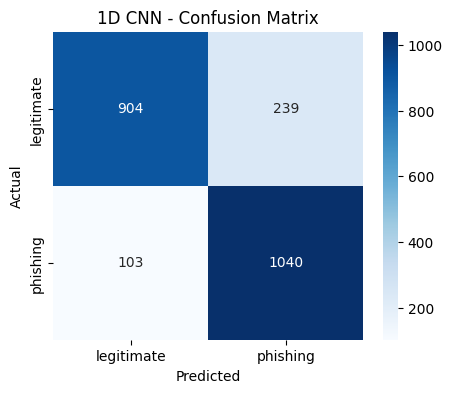


===== LSTM =====
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5469 - loss: 0.6755 - val_accuracy: 0.6809 - val_loss: 0.5619
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6806 - loss: 0.5797 - val_accuracy: 0.7945 - val_loss: 0.4466
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7808 - loss: 0.4677 - val_accuracy: 0.7945 - val_loss: 0.4304
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7858 - loss: 0.4522 - val_accuracy: 0.7639 - val_loss: 0.4791
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7806 - loss: 0.4524 - val_accuracy: 0.7945 - val_loss: 0.4328
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7851 - loss: 0.4473 - val_accuracy: 0.8066 - val_loss: 0.4033
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7806 - loss: 0.4435 - val_accuracy: 0.7956 - val_loss: 0.4181
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7867 - loss: 0.4481

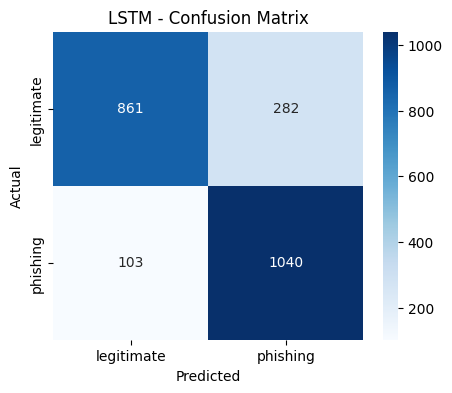


===== BiLSTM =====
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6507 - loss: 0.5854 - val_accuracy: 0.7989 - val_loss: 0.4183
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7782 - loss: 0.4526 - val_accuracy: 0.8077 - val_loss: 0.4101
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7941 - loss: 0.4287 - val_accuracy: 0.7749 - val_loss: 0.4406
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7931 - loss: 0.4188 - val_accuracy: 0.8153 - val_loss: 0.4032
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8103 - loss: 0.4109 - val_accuracy: 0.8022 - val_loss: 0.4008
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7979 - loss: 0.4110 - val_accuracy: 0.8033 - val_loss: 0.3967
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8102 - loss: 0.4012 - val_accuracy: 0.7902 - val_loss: 0.4097
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8006 - loss: 0.4

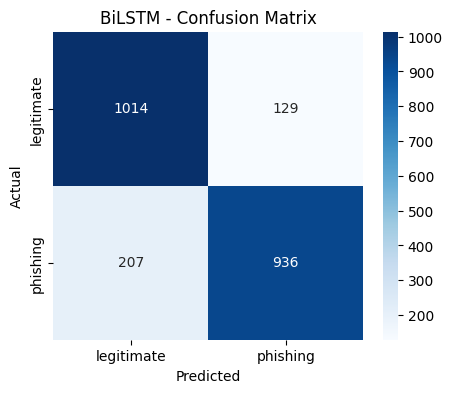


=== Deep Learning Model Performance Comparison ===
    Model  Accuracy  Precision    Recall  F1 Score       MCC
0  1D CNN  0.850394   0.855426  0.850394  0.849862  0.705801
1    LSTM  0.831584   0.839920  0.831584  0.830545  0.671452
2  BiLSTM  0.853018   0.854670  0.853018  0.852847  0.707686


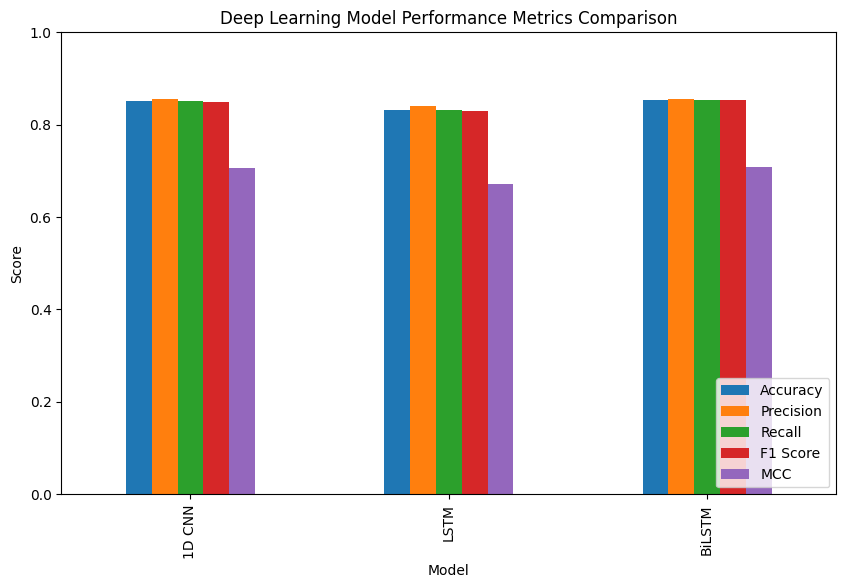

In [11]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import re
import warnings
warnings.filterwarnings("ignore")  # suppress other warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Word2Vec
from gensim.models import Word2Vec

# ================================
# 2. Load Raw URL Dataset
# ================================
df = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")
print("Data shape:", df.shape)
print(df.head())

# ================================
# 3. Encode Labels
# ================================
le = LabelEncoder()
y = le.fit_transform(df["status"].values)  # 'legitimate' -> 0, 'phishing' -> 1
num_classes = len(np.unique(y))
y_categorical = to_categorical(y, num_classes=num_classes)

# ================================
# 4. Tokenize URLs & Train Word2Vec
# ================================
def tokenize_url(url):
    tokens = re.split(r'[./:?&=]', url)
    tokens = [t for t in tokens if t]
    return tokens

sentences = df['url'].astype(str).apply(tokenize_url).tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

def url_to_vec(url, max_len=50):
    tokens = tokenize_url(url)
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if len(vecs) == 0:
        vecs = [np.zeros(100)]
    # Pad/truncate to max_len
    if len(vecs) < max_len:
        vecs += [np.zeros(100)] * (max_len - len(vecs))
    else:
        vecs = vecs[:max_len]
    return np.array(vecs)

X = np.array(df['url'].astype(str).apply(url_to_vec).tolist())
print("Feature matrix shape:", X.shape)  # (samples, max_len, embedding_dim)

# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Define Deep Learning Models
# ================================
def build_1d_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

models = {
    "1D CNN": build_1d_cnn(X_train.shape[1:], num_classes),
    "LSTM": build_lstm(X_train.shape[1:], num_classes),
    "BiLSTM": build_bilstm(X_train.shape[1:], num_classes)
}

# ================================
# 7. Train, Predict & Collect Metrics
# ================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

metrics_results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        verbose=1,
        callbacks=[early_stop]
    )
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)
    
    metrics_results.append([name, acc, prec, rec, f1, mcc])
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Free memory
    del y_pred, y_pred_probs, cm, history
    gc.collect()

# ================================
# 8. Compare Models in Table
# ================================
results_df = pd.DataFrame(
    metrics_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
)

print("\n=== Deep Learning Model Performance Comparison ===")
print(results_df)

# ================================
# 9. Plot Model Comparison
# ================================
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Deep Learning Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


In [12]:
# FastText Algorithm-DL Models Now Lets Include the patience

Data shape: (11430, 89)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0         

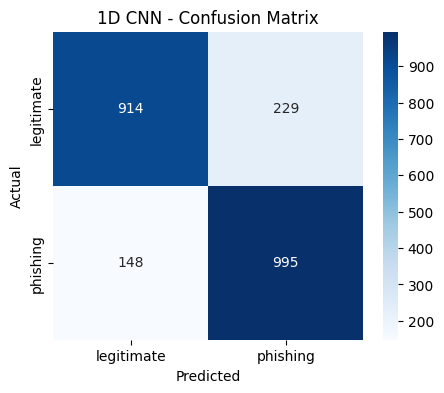


===== LSTM =====
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5518 - loss: 0.6702 - val_accuracy: 0.6623 - val_loss: 0.5938
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6450 - loss: 0.6167 - val_accuracy: 0.6415 - val_loss: 0.6129
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6614 - loss: 0.6041 - val_accuracy: 0.7694 - val_loss: 0.5029
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7751 - loss: 0.4835 - val_accuracy: 0.8000 - val_loss: 0.4329
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7907 - loss: 0.4532 - val_accuracy: 0.7847 - val_loss: 0.4494
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7949 - loss: 0.4359 - val_accuracy: 0.7956 - val_loss: 0.4229
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8062 - loss: 0.4060 - val_accuracy: 0.8022 - val_loss: 0.4206
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8051 - loss: 0.4155

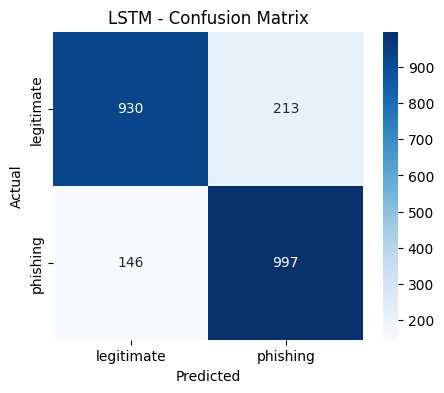


===== BiLSTM =====
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6284 - loss: 0.6177 - val_accuracy: 0.7760 - val_loss: 0.4490
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7769 - loss: 0.4606 - val_accuracy: 0.7989 - val_loss: 0.4182
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7871 - loss: 0.4398 - val_accuracy: 0.8011 - val_loss: 0.4071
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7929 - loss: 0.4243 - val_accuracy: 0.8033 - val_loss: 0.3948
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7896 - loss: 0.4300 - val_accuracy: 0.7661 - val_loss: 0.4264
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8019 - loss: 0.4180 - val_accuracy: 0.8208 - val_loss: 0.3799
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8056 - loss: 0.4054 - val_accuracy: 0.8175 - val_loss: 0.3842
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8061 - loss: 0.39

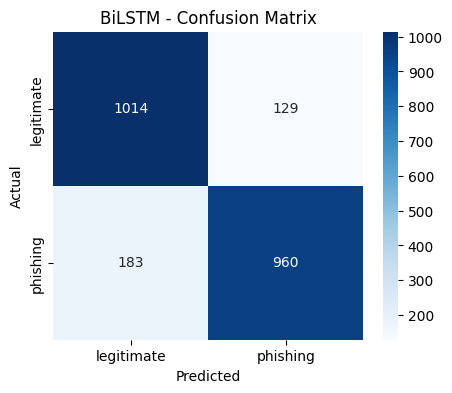


=== Deep Learning Model Performance Comparison ===
    Model  Accuracy  Precision    Recall  F1 Score       MCC
0  1D CNN  0.835083   0.836774  0.835083  0.834876  0.671855
1    LSTM  0.842957   0.844140  0.842957  0.842822  0.687096
2  BiLSTM  0.863517   0.864330  0.863517  0.863441  0.727847


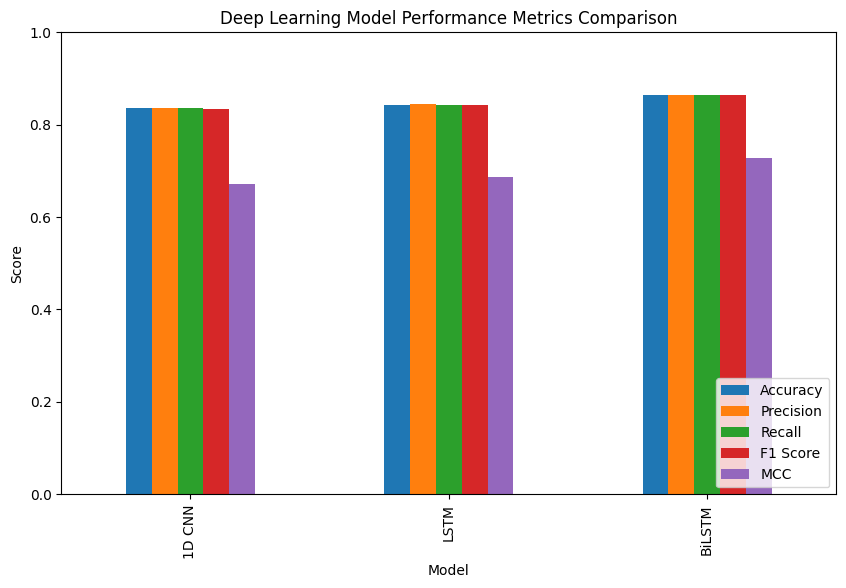

In [13]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import re
import warnings
warnings.filterwarnings("ignore")  # suppress warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# FastText
from gensim.models import FastText

# ================================
# 2. Load Raw URL Dataset
# ================================
df = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")
print("Data shape:", df.shape)
print(df.head())

# ================================
# 3. Encode Labels
# ================================
le = LabelEncoder()
y = le.fit_transform(df["status"].values)  # 'legitimate' -> 0, 'phishing' -> 1
num_classes = len(np.unique(y))
y_categorical = to_categorical(y, num_classes=num_classes)

# ================================
# 4. Tokenize URLs & Train FastText
# ================================
def tokenize_url(url):
    tokens = re.split(r'[./:?&=]', url)
    tokens = [t for t in tokens if t]
    return tokens

sentences = df['url'].astype(str).apply(tokenize_url).tolist()

# Train FastText model
ft_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

def url_to_vec(url, max_len=50):
    tokens = tokenize_url(url)
    vecs = [ft_model.wv[t] for t in tokens if t in ft_model.wv]
    if len(vecs) == 0:
        vecs = [np.zeros(100)]
    # Pad/truncate to max_len
    if len(vecs) < max_len:
        vecs += [np.zeros(100)] * (max_len - len(vecs))
    else:
        vecs = vecs[:max_len]
    return np.array(vecs)

X = np.array(df['url'].astype(str).apply(url_to_vec).tolist())
print("Feature matrix shape:", X.shape)

# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Define Deep Learning Models
# ================================
def build_1d_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

models = {
    "1D CNN": build_1d_cnn(X_train.shape[1:], num_classes),
    "LSTM": build_lstm(X_train.shape[1:], num_classes),
    "BiLSTM": build_bilstm(X_train.shape[1:], num_classes)
}

# ================================
# 7. Train, Predict & Collect Metrics
# ================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

metrics_results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        verbose=1,
        callbacks=[early_stop]
    )
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)
    
    metrics_results.append([name, acc, prec, rec, f1, mcc])
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    del y_pred, y_pred_probs, cm, history
    gc.collect()

# ================================
# 8. Compare Models in Table
# ================================
results_df = pd.DataFrame(
    metrics_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
)

print("\n=== Deep Learning Model Performance Comparison ===")
print(results_df)

# ================================
# 9. Plot Model Comparison
# ================================
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Deep Learning Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


In [ ]:
#phishdump Transformers-ML Models

In [ ]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ================================
# 2. Load Dataset + Embeddings
# ================================
# raw dataset (for labels)
df = pd.read_csv("/kaggle/input/phishdumpdatasetn/Dataset_Phishdump.csv")

# embeddings parquet (must align row-wise with df)
embeddings_df = pd.read_parquet("/kaggle/input/phishdumpbertvectors/phishdumpbert_embeddings.parquet")

print("Dataset shape:", df.shape)
print("Embeddings shape:", embeddings_df.shape)

# sanity check: both must have same number of rows
assert len(df) == len(embeddings_df), "Dataset and embeddings row count mismatch!"

# ================================
# 3. Prepare Features & Labels
# ================================
X = np.vstack(embeddings_df["embedding"].values)   # convert list of embeddings into numpy array
le = LabelEncoder()
y = le.fit_transform(df["status"].values)

print("Feature matrix:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", le.classes_)

# ================================
# 4. Train-Test Split (no leakage)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

# ================================
# 5. Define Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

# ================================
# 6. Train, Predict & Collect Metrics
# ================================
metrics_results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)
    
    metrics_results.append([name, acc, prec, rec, f1, mcc])
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Free memory
    del y_pred, cm
    gc.collect()

# ================================
# 7. Compare Models in Table
# ================================
results_df = pd.DataFrame(
    metrics_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC"]
)

print("\n=== Model Performance Comparison ===")
print(results_df)

# ================================
# 8. Plot Model Comparison
# ================================
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()